# Automatic MoE Routing Bandaid on v3: availability gate + soft blend, no global fallback
## `derived_8.4-ece-router-salvage-2.0`

Manual routing overrides (`c0_only`, transplants) close the ECE gap but are not
deployable: they peek at the target to pick the winner. This experiment replaces
them with an **automatic, input-only bandaid** that only activates when routing
inputs are missing/unreliable and never leaves the MoE (every MoE prediction is
`w0*E0 + w1*E1` of the same two frozen regime experts). Experts, routers, margin
cutoffs, gate rule, and softmax temperature are all fit on WA `trainval` /
`train`+`val` only; `derived_8.4_ece_v3` targets are eval-only. `c0_only` is kept
purely as a MANUAL oracle ceiling (`deployable=false`). `Global_Single_54`
(`policy=direct`) is a single-regime baseline reference row only, fit on WA
`trainval` like the experts and never used as a fallback.


## 1. Load the versioned experiment implementation
The notebook imports the tracked runner instead of duplicating logic, so results
reproduce from a clean checkout. Paths resolve from the repository root.


In [1]:
from pathlib import Path
import importlib.util
import sys

cur = Path.cwd().resolve()
while cur != cur.parent:
    if (cur / "data" / "splits").exists() and (cur / "notebooks").exists():
        PROJECT_ROOT = cur
        break
    cur = cur.parent

EXP_DIR = PROJECT_ROOT / "notebooks/experiment/derived_8.4-ece-router-salvage-2.0"
sys.path.insert(0, str(EXP_DIR))
RUNNER_PATH = EXP_DIR / "run_auto.py"
spec = importlib.util.spec_from_file_location("router_auto_salvage", RUNNER_PATH)
salvage = importlib.util.module_from_spec(spec)
spec.loader.exec_module(salvage)
config = salvage.load_configuration()
print(f"Experiment: {config['experiment']['name']}")
print(f"Families: {config['families']}")
print(f"Policies: {config['policies']}")
print(f"Deployable: {config['deployable']}")
print(f"Oracle: {config['oracle']}")
print(f"Seeds: {config['seeds']}")
print(f"Constraint: {config['experiment']['constraint']}")


Experiment: derived_8.4-ece-router-salvage-2.0
Families: ['Clustering_V0_Full_k2', 'Clustering_Backbone54_k2']
Policies: ['as_routed', 'soft_static', 'auto_hard', 'auto_soft', 'auto_soft_T2', 'auto_equal', 'c0_only']
Deployable: ['as_routed', 'soft_static', 'auto_hard', 'auto_soft', 'auto_soft_T2', 'auto_equal', 'direct']
Oracle: ['c0_only']
Seeds: [42, 7, 13, 101, 123]
Constraint: ECE strictly unseen; experts and the Global_Single_54 baseline fit on WA trainval only; every MoE prediction is a convex combo of the two frozen regime experts (w0*E0 + w1*E1); the baseline is a direct reference row only (never used as fallback/transplant); no manual per-station override.


## 2. Run the automatic salvage on v3
Fits routers + experts + the Global_Single_54 baseline on WA `trainval` only,
calibrates temperature and gate on WA `train`/`val` only (ECE never touched),
then scores v3 under each policy. Per-seed checkpoints resume, so re-execution
is fast when artifacts exist. From a clean checkout this cell trains
(documented timeout 3600s, CPU).


In [2]:
salvage.main([])  # [] = defaults; avoids parsing the kernel's argv


WA margin p5: v0=1.9560 backbone=1.5481
WA margin median: v0=3.5769 backbone=3.6499


WA-tuned temperatures: {'v0': 0.25, 'backbone': 0.25}
WA calibration (train-fit / val-scored,incl. synthetic SMAP masking):
  Clustering_V0_Full_k2 clean_val soft_static_T0.25: rmse=0.054241
  Clustering_V0_Full_k2 clean_val soft_static_T0.5: rmse=0.054286
  Clustering_V0_Full_k2 clean_val soft_static_T1: rmse=0.054794
  Clustering_V0_Full_k2 clean_val soft_static_T2: rmse=0.057275
  Clustering_V0_Full_k2 smap_masked_val static_hard_masked: rmse=0.068082
  Clustering_V0_Full_k2 smap_masked_val aux_hard_masked: rmse=0.072757
  Clustering_V0_Full_k2 clean_val static_hard_clean: rmse=0.054241
  Clustering_V0_Full_k2 clean_val aux_hard_clean: rmse=0.073736
  Clustering_Backbone54_k2 clean_val soft_static_T0.25: rmse=0.054243
  Clustering_Backbone54_k2 clean_val soft_static_T0.5: rmse=0.054302
  Clustering_Backbone54_k2 clean_val soft_static_T1: rmse=0.054992
  Clustering_Backbone54_k2 clean_val soft_static_T2: rmse=0.057390
  Clustering_Backbone54_k2 smap_masked_val static_hard_masked: rms

## 3. Policy comparison (deployable vs oracle) + WA calibration
Pooled RMSE / bias per policy on v3. `deployable=false` rows (`c0_only`) are the
manual oracle ceiling — the deployable claim is `auto_*`/`soft_static` vs
`as_routed`. The WA calibration table underneath proves `T` and the gate regime
were selected without ECE.


In [3]:
import json
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

summary = pd.read_csv(EXP_DIR / "summary.csv")
seed_metrics = pd.read_csv(EXP_DIR / "seed_metrics.csv")
calibration = pd.read_csv(EXP_DIR / "wa_calibration.csv")
with (EXP_DIR / "routing_audit.json").open(encoding="utf-8") as f:
    audit = json.load(f)
print(f"WA margin thresholds: {audit['wa_thresholds']}")
print(f"WA medians: {audit['wa_medians']}")
print(f"WA temperatures: {audit['temperatures']}")
print(summary.to_string(index=False))
print(calibration.to_string(index=False))

deployable = summary[(summary["deployable"] == True)
                    & (summary["family"].isin(config["families"]))]
order = [p for p in config["policies"] if p in set(deployable["policy"])]
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, (family, sub) in zip(axes, deployable.groupby("family")):
    panel = sub.set_index("policy").reindex(order)
    ax.bar(panel.index, panel["rmse_mean"], yerr=panel["rmse_std"], capsize=3)
    oracle = summary.query("family == @family and policy == 'c0_only'")
    if not oracle.empty:
        ax.axhline(float(oracle["rmse_mean"].iloc[0]), linestyle=":", color="gray",
                   label="c0_only oracle (manual)")
    ax.set_title(f"{family} (v3 ECE, deployable)")
    ax.set_ylabel("pooled RMSE (m3/m3)")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(fontsize=8)
fig.tight_layout()
(EXP_DIR / "figures").mkdir(exist_ok=True)
fig.savefig(EXP_DIR / "figures" / "policy_rmse_deployable_v3.png", dpi=150)
print("Saved figures/policy_rmse_deployable_v3.png")


WA margin thresholds: {'v0': 1.9559823212899237, 'backbone': 1.5480887296641908}
WA medians: {'v0': 3.576934535557384, 'backbone': 3.6499401378874268}
WA temperatures: {'v0': 0.25, 'backbone': 0.25}
                  family ece_input       policy  deployable  rmse_mean  rmse_std  mae_mean  bias_mean  ubrmse_mean    r2_mean  pearson_mean  rmse_change_vs_as_routed  rmse_gap_vs_oracle_c0
   Clustering_V0_Full_k2        v3    as_routed        True   0.165908  0.003051  0.139226   0.117727     0.116899 -11.438029     -0.669629                  0.000000           1.081397e-01
   Clustering_V0_Full_k2        v3  soft_static        True   0.141739  0.002595  0.123158   0.115581     0.082038  -8.078087     -0.685431                 -0.024169           8.397068e-02
   Clustering_V0_Full_k2        v3    auto_hard        True   0.057768  0.000617  0.050167   0.028654     0.050158  -0.507705      0.103776                 -0.108140           0.000000e+00
   Clustering_V0_Full_k2        v3    auto_so

Saved figures/policy_rmse_deployable_v3.png


## 4. Station-level verdict + gate/blend audit
Compares deployable `auto_*` against `as_routed` station by station and checks
the gate fired for the right (input-only) reason with MoE-internal weights.


In [4]:
import json
import pandas as pd

station = pd.read_csv(EXP_DIR / "station_metrics.csv")
pivot = station.groupby(["family", "ece_input", "policy", "station"], sort=False)["rmse"].mean().unstack("station")
print(pivot.to_string(float_format=lambda v: f"{v:.6f}"))
v3 = pivot.xs("v3", level="ece_input")
for family in config["families"]:
    base = v3.loc[(family, "as_routed")].mean()
    oracle = v3.loc[(family, "c0_only")].mean()
    for policy in config["deployable"]:
        if policy in ("as_routed", "direct"):
            continue  # reference rows have no per-family MoE entry
        val = v3.loc[(family, policy)].mean()
        print(f"{family} {policy}: as_routed={base:.6f} -> {policy}={val:.6f} "
              f"(delta={val - base:+.6f}, gap_vs_oracle={val - oracle:+.6f})")

with (EXP_DIR / "routing_audit.json").open(encoding="utf-8") as f:
    audit = json.load(f)
for entry in audit["seeds"]:
    for family in config["families"]:
        auto = entry["policies"][family]["auto_soft"]
        print(f"seed={entry['seed']} {family} auto_soft: gate_share={auto.get('gate_share'):.3f} "
              f"ambiguous_share={auto.get('ambiguous_share'):.3f} mean_w0={auto.get('mean_w0'):.3f} "
              f"c0_share={auto.get('c0_share'):.3f}")


station                                          ECE_BBG_Lost_Meadow  ECE_BBG_Main_St  ECE_Renton_Garden_North  ECE_Renton_Garden_Shed  ECE_Renton_Home
family                   ece_input policy                                                                                                              
Clustering_V0_Full_k2    v3        as_routed                0.198791         0.190692                 0.056877                0.034239         0.239447
                                   soft_static              0.168947         0.161328                 0.027573                0.069069         0.200862
                                   auto_hard                0.047951         0.049039                 0.056877                0.034239         0.087015
                                   auto_soft                0.047951         0.049039                 0.056877                0.034239         0.087015
                                   auto_soft_T2             0.067849         0.071043   

## 5. Per-station prediction line charts (≤5 lines per chart)
Seed-mean observed vs predicted trajectories from `predictions_v3.csv`: 10
family panels (5 stations × V0 / Backbone: observed + as_routed / auto_soft /
auto_hard + c0_only oracle) plus one deployable overlay. Every panel enforces
the 5-line maximum.


Stations: ['ECE_BBG_Lost_Meadow', 'ECE_BBG_Main_St', 'ECE_Renton_Garden_North', 'ECE_Renton_Garden_Shed', 'ECE_Renton_Home']
Saved 11 figures:
  figures/timeseries_v3_ECE_BBG_Lost_Meadow_v0.png
  figures/timeseries_v3_ECE_BBG_Main_St_v0.png
  figures/timeseries_v3_ECE_Renton_Garden_North_v0.png
  figures/timeseries_v3_ECE_Renton_Garden_Shed_v0.png
  figures/timeseries_v3_ECE_Renton_Home_v0.png
  figures/timeseries_v3_ECE_BBG_Lost_Meadow_backbone.png
  figures/timeseries_v3_ECE_BBG_Main_St_backbone.png
  figures/timeseries_v3_ECE_Renton_Garden_North_backbone.png
  figures/timeseries_v3_ECE_Renton_Garden_Shed_backbone.png
  figures/timeseries_v3_ECE_Renton_Home_backbone.png
  figures/timeseries_v3_auto_overlay.png


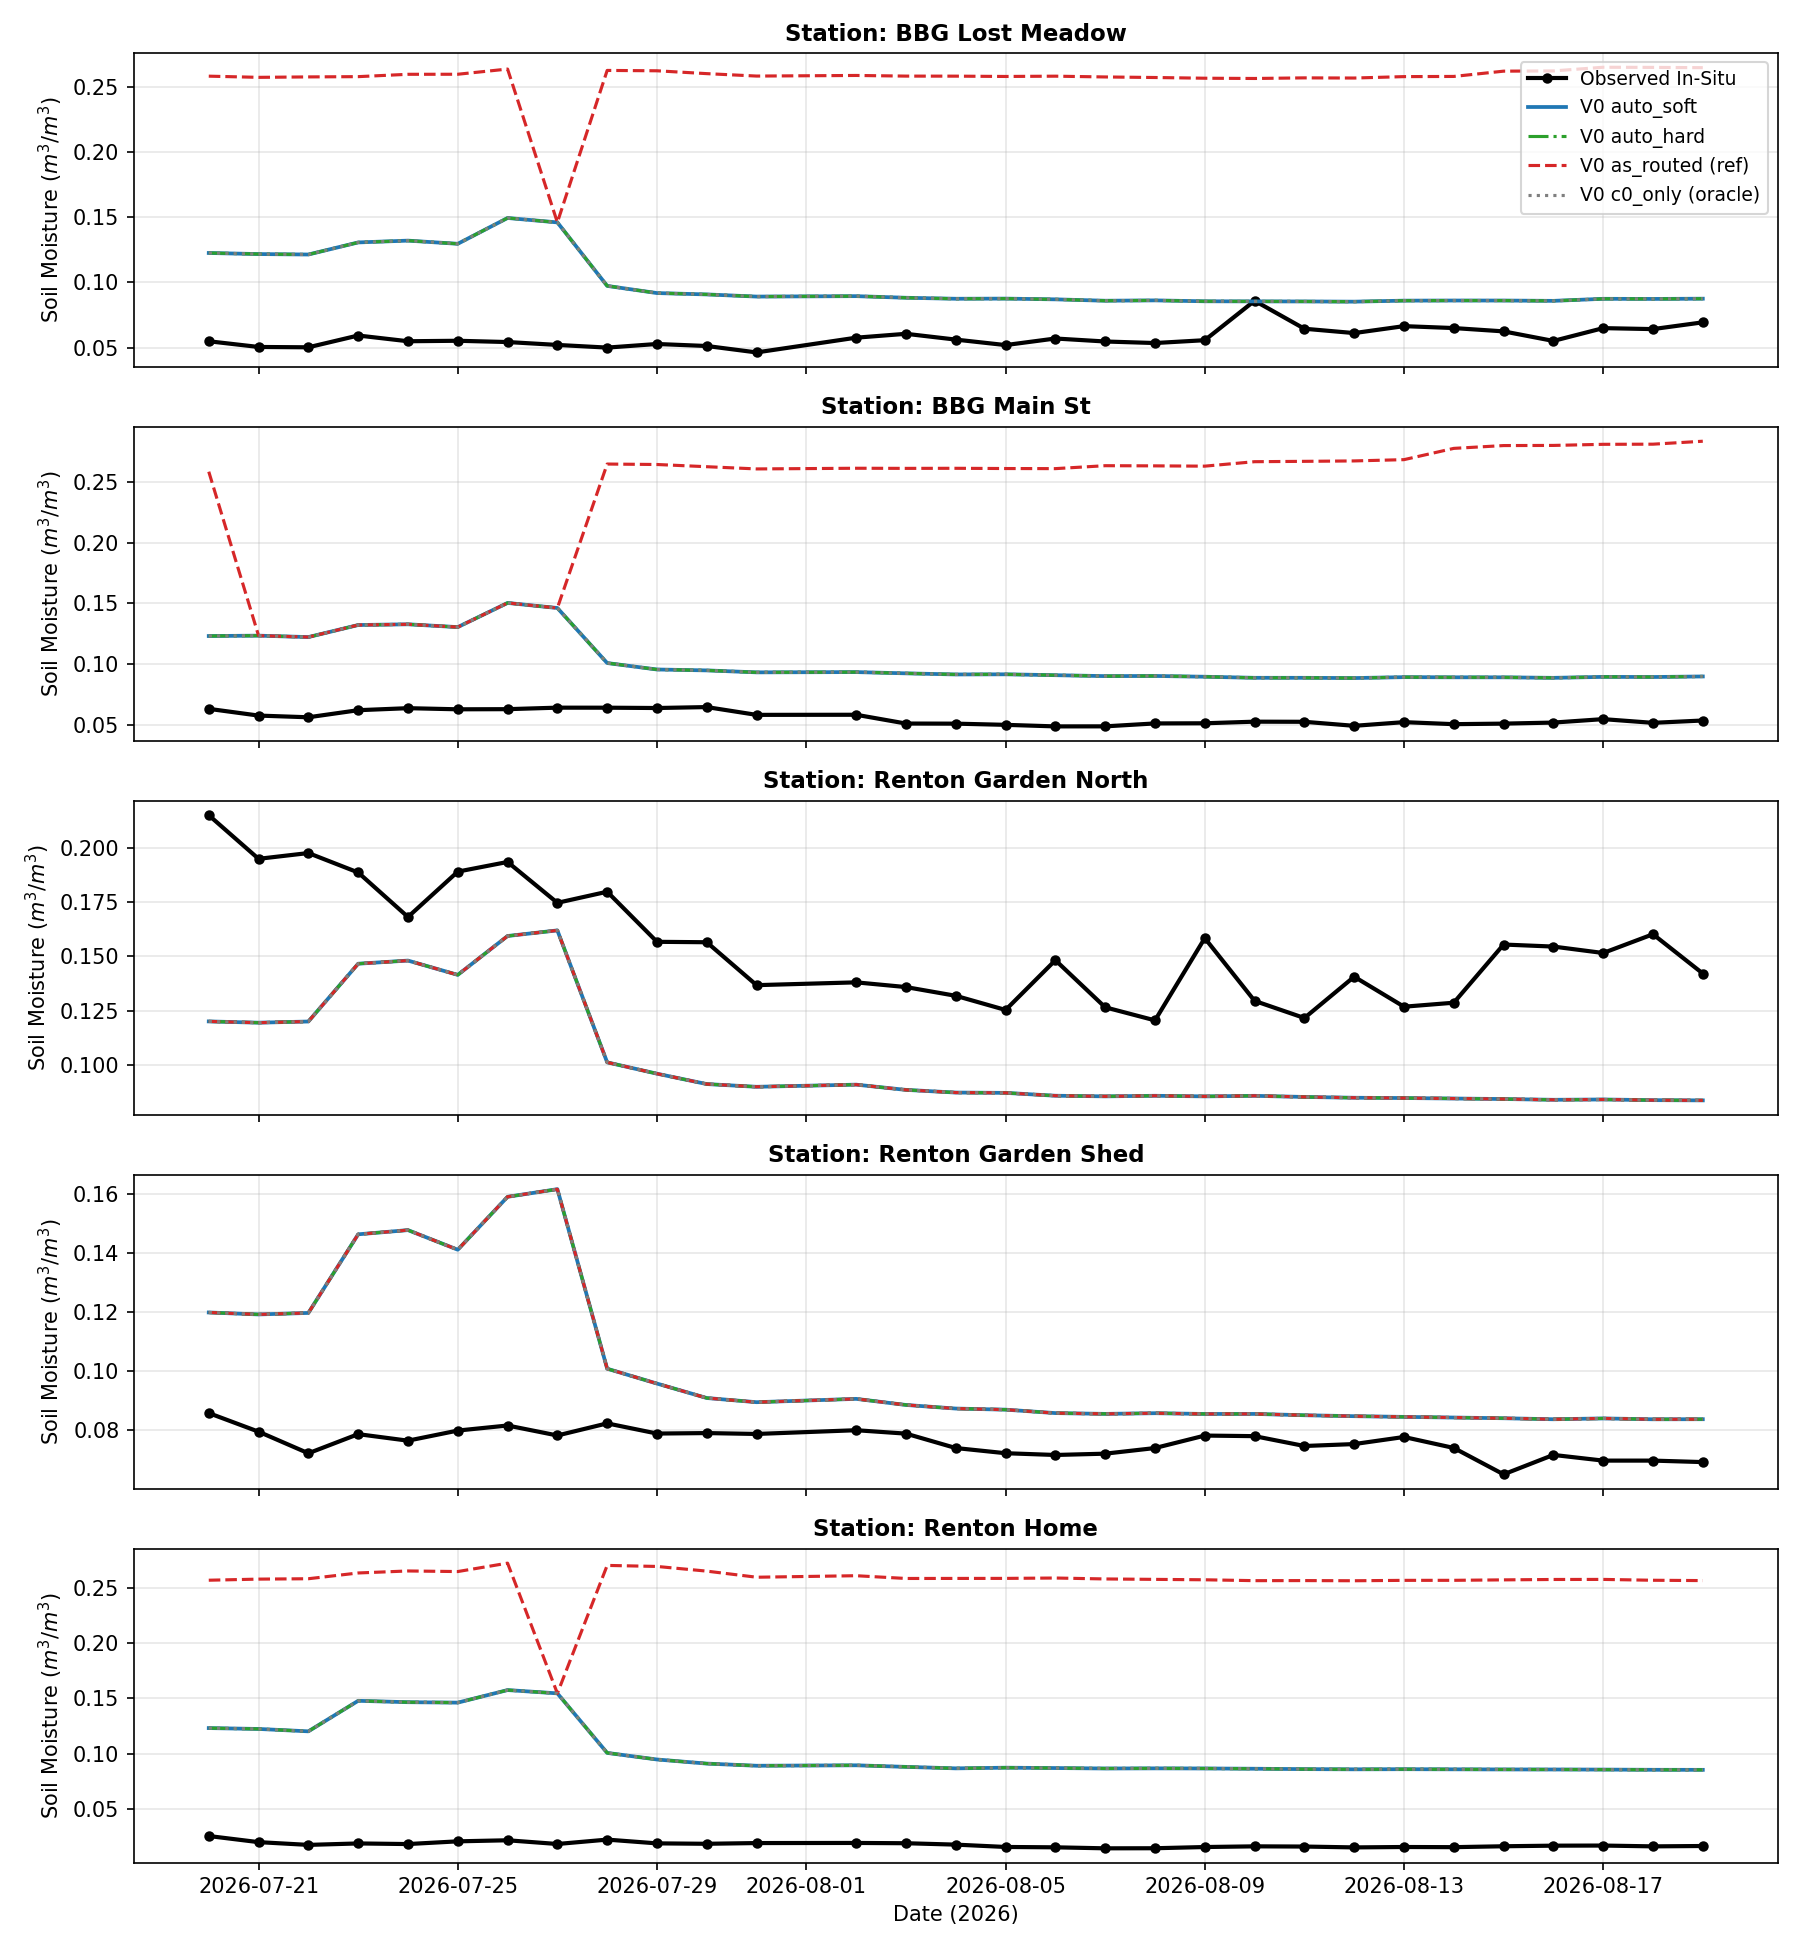

In [5]:
import importlib.util

PLOT_PATH = EXP_DIR / "plot_timeseries.py"
plot_spec = importlib.util.spec_from_file_location("auto_plots", PLOT_PATH)
plots = importlib.util.module_from_spec(plot_spec)
plot_spec.loader.exec_module(plots)
plots.main([])

from IPython.display import Image, display
display(Image(str(EXP_DIR / "figures" / "timeseries_v3_auto_overlay.png")))
